In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


The given input function is: 
\begin{equation}
u(t) = \max \left( 0.15, \frac{1}{2} \left(\omega_1 \omega_2 + \omega_1 ^ 3 + \frac{1}{2}\right) \right)
\end{equation}

\begin{equation}
\omega_1 = \sin(75t)
\end{equation}

\begin{equation}
\omega_2 = 75 \cos(75t)
\end{equation}

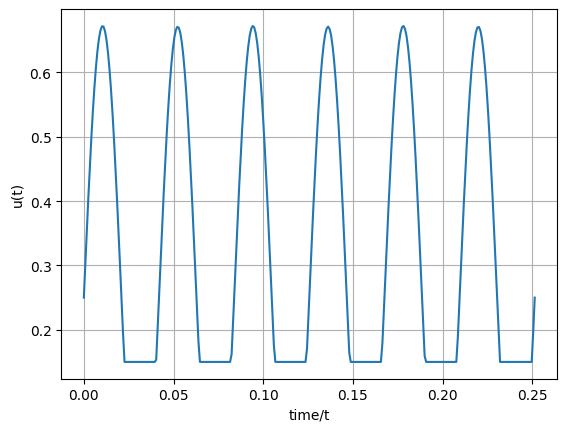

In [34]:
def u(t):
    omega1 = 0.15* np.sin(75*t)
    omega2 = 0.15* 75 * np.cos(75*t)

    func = (0.5 * ( omega1 * omega2 + omega1 ** 3 + 0.5))

    return np.where( func < 0.15, 0.15, func)

T = np.linspace(0, (6*np.pi) / 75, 300)
U = u(T)

plt.plot(T, U)
plt.grid(True)
plt.ylabel("u(t)")
plt.xlabel("time/t")
plt.show()





The averaged model of the Cuk converter is: 
yadayada


C:\Users\yoonj\AppData\Local\Temp\ipykernel_26492\2332548208.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


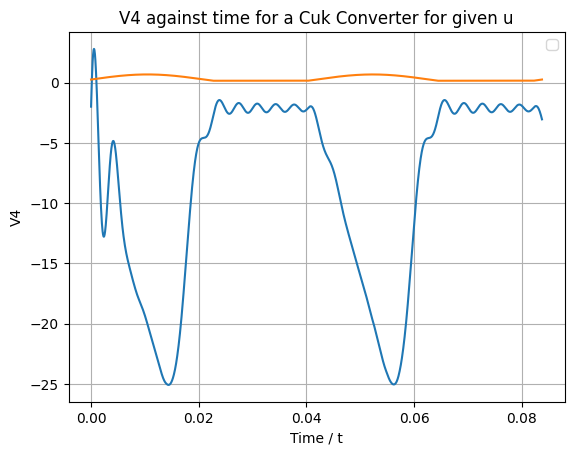

In [36]:
L1 = 10.0e-3
C2 = 22.0e-6
L3 = 10.0e-3
C4 = 22.9e-6
G = 0.0447
E = 12.0

def Cukconverter(t, x):
    x1, x2, x3, x4 = x
    u_val = u(t)

    dx1 = ( -(1.0 - u_val)*x2 + E) / L1
    dx2 = ( (1.0 - u_val ) * x1 + u_val*x3) / C2
    dx3 = (-u_val * x2 - x4) / L3
    dx4 = ( x3 - G*x4) / C4

    return [dx1, dx2, dx3, dx4]

x0 = [0.5, 0.4, 0.3, -2]
t_span = (0, (2 * np.pi) / 75)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Solve
sol = solve_ivp(Cukconverter, t_span, x0, t_eval=t_eval)

T_list = sol.t
v4_list = sol.y[3]  # x4

plt.plot(T_list, v4_list)
plt.plot(T_list, u(T_list))
plt.grid(True)
plt.legend()
plt.xlabel("Time / t")
plt.ylabel("V4")
plt.title("V4 against time for a Cuk Converter for given u")
plt.show()




REDUCED ORDER MODEL 